# **Assessment 13: Text Clustering & Topic Modeling**

**Submitted by:**
* Benedict S. Caliba
* Marcelo B. Cosme
* Aaron Kane M. Dungca
  
**Date Submitted:** May 13, 2026

---

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import normalize

import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

from collections import Counter

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("All libraries loaded!")

All libraries loaded!


# **Preprocessing & Vectorization**

### **Load dataset**

In [2]:
# Load the dataset
df = pd.read_csv("IMDB Dataset.csv")
print(df.columns)

Index(['review', 'sentiment'], dtype='str')


In [3]:
print("First five rows:")
print(df.head())
print(f"\nDataset shape: {df.shape}")

First five rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Dataset shape: (50000, 2)


### **Take a sample distribution**

In [4]:
df_sample = df.sample(n=2000, random_state=42).reset_index().copy()

# Display head rows
print("Sample Distribution:")
print(df_sample['sentiment'].value_counts())

Sample Distribution:
sentiment
negative    1024
positive     976
Name: count, dtype: int64


### **Create preprocess function**

In [5]:
def preprocess(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove HTML tags (using regex)
    text = re.sub(r'<.*?>', '', text)

    # 3. Remove punctuation and numbers
    # Keeps only alphabetical characters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Tokenization
    tokens = word_tokenize(text)

    # 5. Remove stop words + custom domain-specific words
    stop_words = set(stopwords.words('english'))
    custom_words = {'film', 'movie', 'one', 'make', 'even',
                    'like', 'would', 'could', 'really', 'much',
                    'dont', 'well', 'time', 'character', 'good',
                    'scene', 'also', 'first', 'many', 'thing',
                    'know', 'look', 'never', 'every', 'doe',
                    'think', 'watch', 'made', 'seen', 'give',
                    'want', 'take', 'say', 'come'}
    stop_words.update(custom_words)

    # 6. Lemmatization
    lemmatizer = WordNetLemmatizer()
    filtered_tokens = [
    lemma for t in tokens
    if len(t) > 3
    for lemma in [lemmatizer.lemmatize(t)]
    if lemma not in stop_words
]

    return ' '.join(filtered_tokens)

# Apply to the review column
processed_docs = [preprocess(doc) for doc in df_sample['review']]
df_sample['cleaned_review'] = processed_docs

# Display the first rows
print("="*65)
print("FIRST 5 ROWS OF THE IMDB REVIEWS DATASET".center(65))
print("="*65 + "\n")
print(df_sample.head())

             FIRST 5 ROWS OF THE IMDB REVIEWS DATASET            

   index                                             review sentiment  \
0  33553  I really liked this Summerslam due to the look...  positive   
1   9427  Not many television shows appeal to quite as m...  positive   
2    199  The film quickly gets to a major chase scene w...  negative   
3  12447  Jane Austen would definitely approve of this o...  positive   
4  39489  Expectations were somewhat high for me when I ...  negative   

                                      cleaned_review  
0  liked summerslam arena curtain overall interes...  
1  television show appeal quite different kind fa...  
2  quickly get major chase ever increasing destru...  
3  jane austen definitely approve onegwyneth palt...  
4  expectation somewhat high went thought steve c...  


### **Create TF-IDF matrix**

In [6]:
# Build TF-IDF matrix
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=3,         # ignore terms appearing in fewer than 3 reviews
    max_df=0.90       # ignore terms appearing in more than 90% of reviews
)

X = tfidf.fit_transform(processed_docs)
X_norm = normalize(X)  # L2 normalize for cosine-like behavior

print(f"TF-IDF matrix shape: {X.shape}")
print(f"(reviews x features)\n")

# Display the total and unique tokens
all_tokens = " ".join(df_sample['cleaned_review']).split()
unique_tokens = set(all_tokens)

print(f"Total tokens:  {len(all_tokens):,}")
print(f"Unique tokens: {len(unique_tokens):,}")

TF-IDF matrix shape: (2000, 2000)
(reviews x features)

Total tokens:  187,736
Unique tokens: 28,025


**Question:** How many unique tokens remain after filtering? Why does `min_df=3` and `max_df=0.90` help reduce noise?

* After filtering, there are 28,054 unique tokens that remain.
* The `min_df=3` helps remove tokens that appear only in less than 3 reviews.
* The `max_df=0.90` suggests that tokens that appears 90% of the reviews will be dropped.
* Together, they reduce noise to produce a non-erroneous outcome in the clustering section.

# **K-Means Text Clustering**

## **Elbow Method and Silhouette Scores**

Computing K-Means for K = 2 to 8...
  K=2: inertia=1924.2, silhouette=0.00299
  K=3: inertia=1915.6, silhouette=0.00306
  K=4: inertia=1911.1, silhouette=0.00316
  K=5: inertia=1907.4, silhouette=0.00377
  K=6: inertia=1902.5, silhouette=0.00185
  K=7: inertia=1898.2, silhouette=0.00384
  K=8: inertia=1896.1, silhouette=0.00382


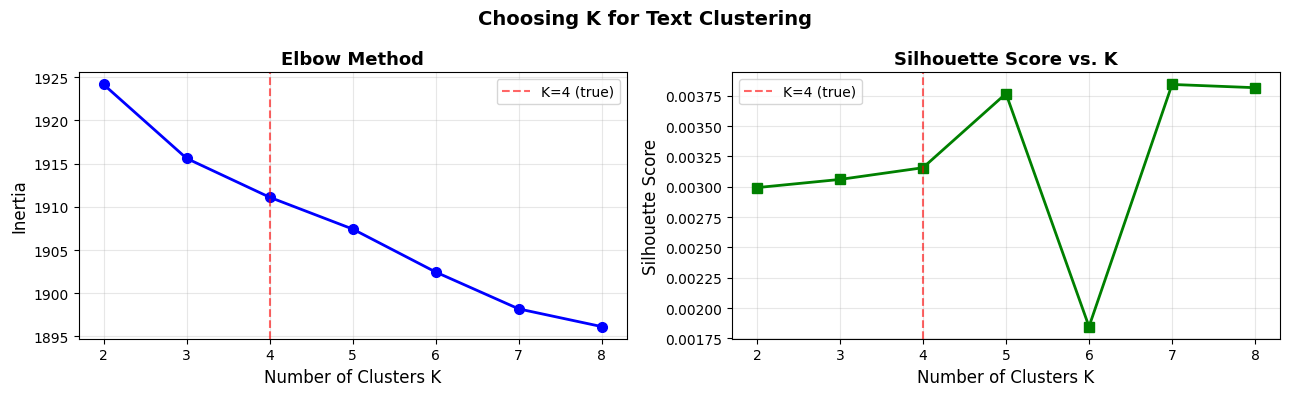


--- Elbow Analysis ---
K      Inertia      ΔInertia       ΔΔInertia   
----------------------------------------------
  2    1924.2       -              -           
  3    1915.6       8.6            -           
  4    1911.1       4.5            4.1         
  5    1907.4       3.7            0.8         
  6    1902.5       5.0            -1.3        
  7    1898.2       4.3            0.7         
  8    1896.1       2.1            2.2         


In [7]:
# Elbow method + Silhouette scores
K_range = range(2, 9)
inertias = []
silhouette_scores = []

print("Computing K-Means for K = 2 to 8...")
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(X_norm)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_norm, km.labels_, sample_size=500, random_state=42)
    silhouette_scores.append(sil)
        
    print(f"  K={k}: inertia={km.inertia_:.1f}, silhouette={sil:.5f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters K', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='K=4 (true)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range), silhouette_scores, 'gs-', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Clusters K', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs. K', fontsize=13, fontweight='bold')
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='K=4 (true)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Choosing K for Text Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Delta Inertia (first difference) ---
# How much inertia drops from K to K+1
delta_inertia = [inertias[i] - inertias[i+1] for i in range(len(inertias) - 1)]

# --- Delta of Delta (second difference) ---
# Where the drop slows down the most = elbow point
delta2_inertia = [delta_inertia[i] - delta_inertia[i+1] for i in range(len(delta_inertia) - 1)]

# K values aligned to each delta
# delta_inertia[0] = drop from K=2 to K=3, so label it at K=3
delta_k    = list(K_range)[1:] 
delta2_k   = list(K_range)[2:]

print("\n--- Elbow Analysis ---")
print(f"{'K':<6} {'Inertia':<12} {'ΔInertia':<14} {'ΔΔInertia':<12}")
print("-" * 46)
for i, k in enumerate(K_range):
    inertia    = inertias[i]
    delta      = delta_inertia[i - 1]  if i > 0 else None
    delta2     = delta2_inertia[i - 2] if i > 1 else None
    print(f"  {k:<4} {inertia:<12.1f} "
          f"{'-' if delta  is None else f'{delta:.1f}':<14} "
          f"{'-' if delta2 is None else f'{delta2:.1f}':<12}")

**Insights:**

Based on both plots, justify your chosen value of K.

* Choosing 4 as the K-value is the best choice as it has the highest drop of `4.1`.
* A k-value of 5 is possible although when dealing with text clustering, it can suffer from curse of dimensionality so k = 4 would be a better choice than k = 5.

## **Display top 15 TF-IDF terms**

In [8]:
# Fit the model with the chosen K
K = 4
km_final = KMeans(
    n_clusters=K,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)
km_final.fit_predict(X_norm)

cluster_labels = km_final.labels_

# Print the top 15 TF-IDF terms per cluster
feature_names = tfidf.get_feature_names_out()

print("Top 15 terms per cluster:\n")
print(f"{'Cluster':<10} {'Top Terms'}")
print("-" * 80)
for i in range(K):
    # Get centroid for this cluster
    centroid = km_final.cluster_centers_[i]
    # Sort features by centroid weight
    top_indices = centroid.argsort()[::-1][:15]
    top_terms = [feature_names[j] for j in top_indices]
    print(f"Cluster {i}:  {', '.join(top_terms)}")

Top 15 terms per cluster:

Cluster    Top Terms
--------------------------------------------------------------------------------
Cluster 0:  ever, acting, worst, funny, watching, plot, waste, better, actor, money, terrible, awful, something, people, nothing
Cluster 1:  people, horror, story, girl, life, little, killer, back, plot, woman, going, something, point, find, kind
Cluster 2:  show, episode, series, season, people, funny, great, life, year, best, still, television, comedy, watching, watched
Cluster 3:  great, story, love, best, performance, play, year, life, actor, work, role, still, music, though, comedy


**DESCRIPTIVE LABELS**

**Cluster 0:** Strongly Negative Reviews

**Cluster 1:** Horror / Thriller

**Cluster 2:** TV Series

**Cluster 3:** Drama / Performance

## **Create cross-tabluation**

In [9]:
# Put clusters in the dataframe
df_sample["cluster"] = km_final.labels_

# Cross-tabulation: cluster vs sentiment
crosstab = pd.crosstab(
    df_sample["cluster"],
    df_sample["sentiment"],
    margins=True,
    margins_name="Total"
)

# Rename index for readability
crosstab.index = [
    "Cluster 1: Strongly Negative Reviews",
    "Cluster 2: Horror / Thriller",
    "Cluster 3: TV Series",
    "Cluster 4: Drama / Performance",
    "Total"
]

print("Cluster vs Sentiment Cross-Tabulation")
print("=" * 45)
print(crosstab)

Cluster vs Sentiment Cross-Tabulation
sentiment                             negative  positive  Total
Cluster 1: Strongly Negative Reviews       420        81    501
Cluster 2: Horror / Thriller               332       187    519
Cluster 3: TV Series                        68        83    151
Cluster 4: Drama / Performance             204       625    829
Total                                     1024       976   2000


**Question:** Does any cluster strongly align with positive or negative reviews?

* Based from the crosstab, Cluster 1 captures the negative sentiments.

## **Reduce the TF-IDF matrix to 2D**

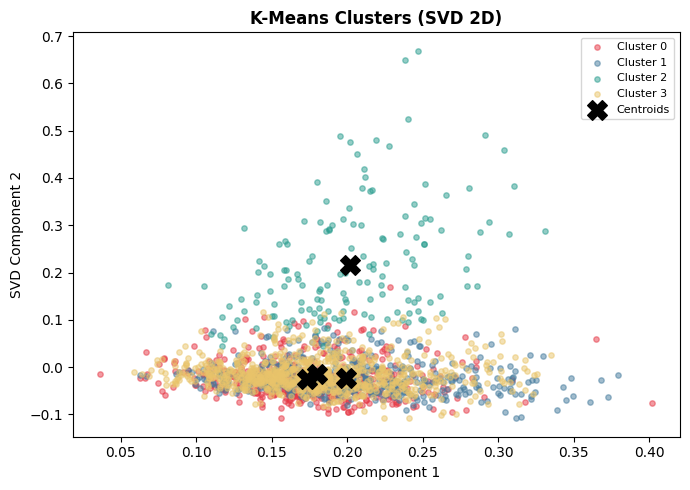

In [10]:
# Reduce to 2D for visualization
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_norm)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A']

# K-Means cluster assignments
for i in range(K):
    mask = cluster_labels == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[i], label=f'Cluster {i}',
               alpha=0.5, s=15)

# Plot centroids projected to 2D
centroids_2d = svd.transform(km_final.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Centroids')

ax.set_title('K-Means Clusters (SVD 2D)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlabel('SVD Component 1')
ax.set_ylabel('SVD Component 2')

plt.tight_layout()
plt.show()

# **LDA Topic Modelling**

## **Prepare the gensim corpus**

In [11]:
# ── Tokenize preprocessed reviews ─────────────────────────────────────────────

tokenized_docs = [doc.split() for doc in df_sample["cleaned_review"]]

# ── Build Dictionary ───────────────────────────────────────────────────────────

dictionary = corpora.Dictionary(tokenized_docs)
print(f"Dictionary size before filtering: {len(dictionary)}")

# ── Filter extremes ────────────────────────────────────────────────────────────

dictionary.filter_extremes(no_below=3, no_above=0.85)
print(f"Dictionary size after filtering:  {len(dictionary)}")

# ── Convert to Bag of Words format ────────────────────────────────────────────

corpus_bow = [dictionary.doc2bow(tokens) for tokens in tokenized_docs]

# ── Preview ────────────────────────────────────────────────────────────────────

print(f"Dictionary size: {len(dictionary)} unique terms")
print(f"Corpus size: {len(corpus_bow)} documents")
print(f"\nSample BoW for doc 0 (first 5 terms):")
for word_id, count in corpus_bow[0][:5]:
    print(f"  '{dictionary[word_id]}': {count}")

Dictionary size before filtering: 28025
Dictionary size after filtering:  7808
Dictionary size: 7808 unique terms
Corpus size: 2000 documents

Sample BoW for doc 0 (first 5 terms):
  'always': 1
  'another': 1
  'anyways': 1
  'best': 1
  'body': 2


## **Train an `LdaModel`**

In [12]:
# Create LdaModel
lda_model = LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=4,
    passes=15,
    alpha='auto',
    eta='auto',
    random_state=42,
    per_word_topics=True
)

print(f"LDA model trained with 4 topics.")
print(f"\nTop 12 words per topic:\n")
for i, topic in lda_model.print_topics(num_words=12):
    print(f"Topic {i}: {topic}")
    print()

LDA model trained with 4 topics.

Top 12 words per topic:

Topic 0: 0.007*"story" + 0.007*"great" + 0.004*"acting" + 0.004*"director" + 0.004*"actor" + 0.003*"plot" + 0.003*"performance" + 0.003*"love" + 0.003*"better" + 0.003*"action" + 0.003*"best" + 0.003*"nothing"

Topic 1: 0.009*"show" + 0.005*"story" + 0.005*"love" + 0.005*"life" + 0.004*"great" + 0.004*"best" + 0.004*"year" + 0.004*"play" + 0.004*"still" + 0.003*"better" + 0.003*"people" + 0.003*"little"

Topic 2: 0.008*"story" + 0.004*"love" + 0.004*"work" + 0.004*"life" + 0.004*"people" + 0.004*"actor" + 0.003*"young" + 0.003*"role" + 0.003*"year" + 0.003*"great" + 0.003*"woman" + 0.003*"performance"

Topic 3: 0.008*"people" + 0.005*"ever" + 0.005*"acting" + 0.004*"story" + 0.004*"plot" + 0.004*"horror" + 0.004*"actually" + 0.004*"something" + 0.004*"worst" + 0.004*"better" + 0.003*"watching" + 0.003*"funny"



## **Compute the coherence score**

Computing coherence scores...
  K=2: coherence = 0.3087
  K=3: coherence = 0.2812
  K=4: coherence = 0.2856
  K=5: coherence = 0.2897
  K=6: coherence = 0.2887
  K=7: coherence = 0.2795


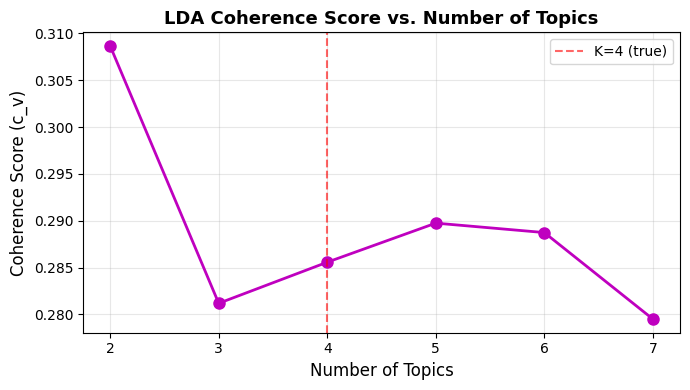

In [13]:
# Compute coherence scores for K = 2 to 7
coherence_scores = []
topic_range = range(2, 8)

print("Computing coherence scores...")
for k in topic_range:
    model = LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=5,
        alpha='auto',
        eta='auto'
    )
    coherence = CoherenceModel(
        model=model,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    ).get_coherence()
    coherence_scores.append(coherence)
    print(f"  K={k}: coherence = {coherence:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(list(topic_range), coherence_scores, 'mo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='K=4 (true)')
plt.xlabel('Number of Topics', fontsize=12)
plt.ylabel('Coherence Score (c_v)', fontsize=12)
plt.title('LDA Coherence Score vs. Number of Topics', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Question:** Which K gives the highest coherence? Does it match the number of topics you used in step 2?

* The K-value of 2 gives the highest coherence although it does not match with the number of topics used in Step 2.

## **Create a bar chart**

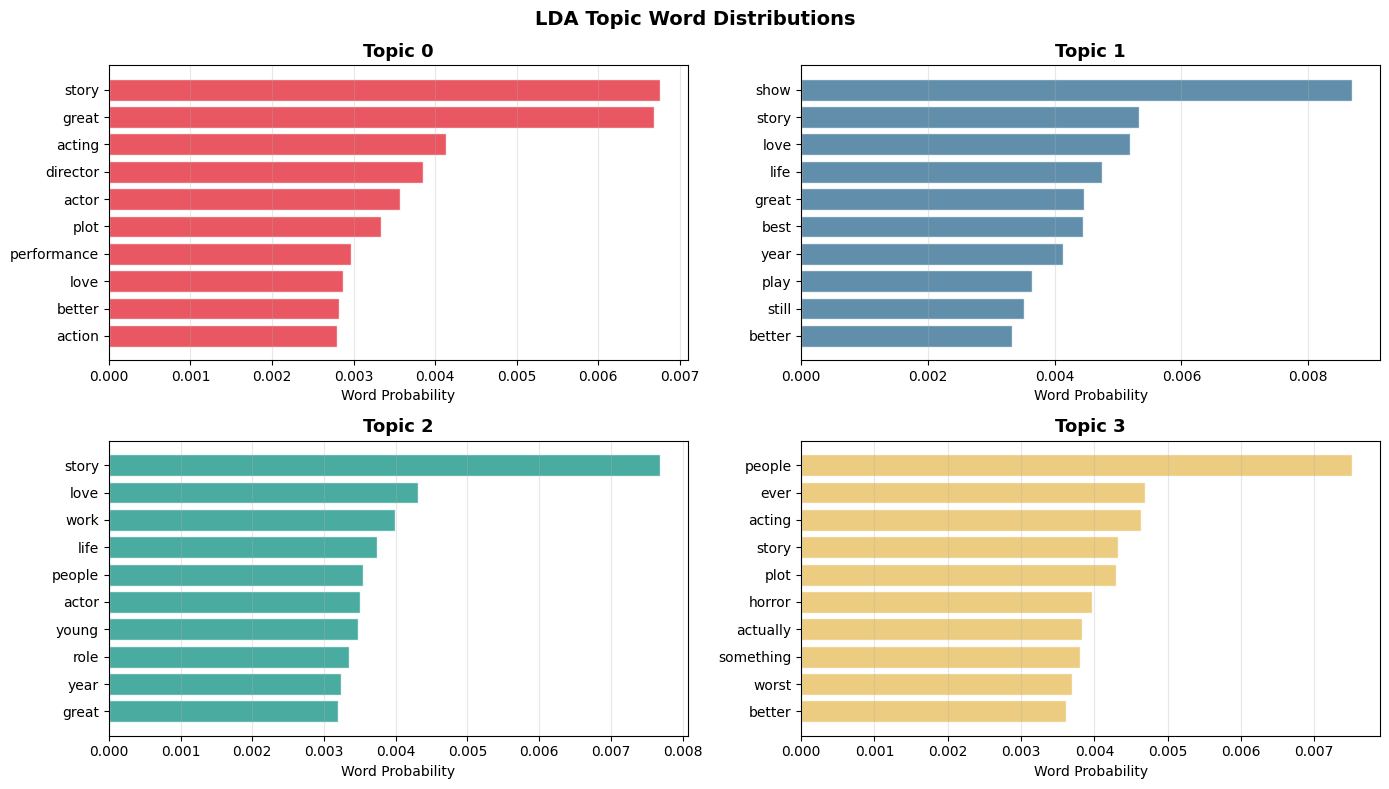

In [14]:
# Bar charts of top words per topic (wordcloud alternative — no extra install needed)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
topic_colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A']

for i in range(4):
    top_words = lda_model.show_topic(i, topn=10)
    words = [w for w, _ in top_words]
    probs = [p for _, p in top_words]

    axes[i].barh(words[::-1], probs[::-1],
                 color=topic_colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Topic {i}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Word Probability', fontsize=10)
    axes[i].tick_params(labelsize=10)
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('LDA Topic Word Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**DESCRIPTIVE LABELS**

**Topic 0:** Action / Film Critique

**Topic 1:** Positive Reviews

**Topic 2:** Drama / Character Study

**Topic 3:** Critical Negative Reviews

# **Document-Topic Analysis**

## **Compute the full topic distribution vector**

In [15]:
# ── Compute topic distribution for each document ──────────────────────────────

def get_topic_vector(bow, num_topics=4):
    """Convert a BoW doc to a full topic probability vector."""
    topic_dist = dict(lda_model.get_document_topics(bow, minimum_probability=0.0))
    return [topic_dist.get(i, 0.0) for i in range(num_topics)]

# Apply to all documents
topic_vectors = [get_topic_vector(bow) for bow in corpus_bow]

# ── Store in DataFrame ─────────────────────────────────────────────────────────

topic_cols = [f"Topic {i}" for i in range(4)]
topic_df = pd.DataFrame(topic_vectors, columns=topic_cols)
topic_df["sentiment"] = df_sample["sentiment"].values

print(f"Shape: {topic_df.shape}")
print("\nSample:")
print(topic_df.head(10).round(4))

Shape: (2000, 5)

Sample:
   Topic 0  Topic 1  Topic 2  Topic 3 sentiment
0   0.0011   0.0015   0.0011   0.9964  positive
1   0.0005   0.0007   0.9979   0.0009  positive
2   0.0014   0.0019   0.4659   0.5308  negative
3   0.0014   0.0019   0.7099   0.2868  positive
4   0.0006   0.2271   0.0006   0.7716  negative
5   0.0003   0.0004   0.0003   0.9990  positive
6   0.9946   0.0018   0.0014   0.0023  positive
7   0.0004   0.0005   0.0004   0.9987  positive
8   0.0006   0.2983   0.0006   0.7004  negative
9   0.9973   0.0009   0.0007   0.0011  negative


## **Create a heatmap**

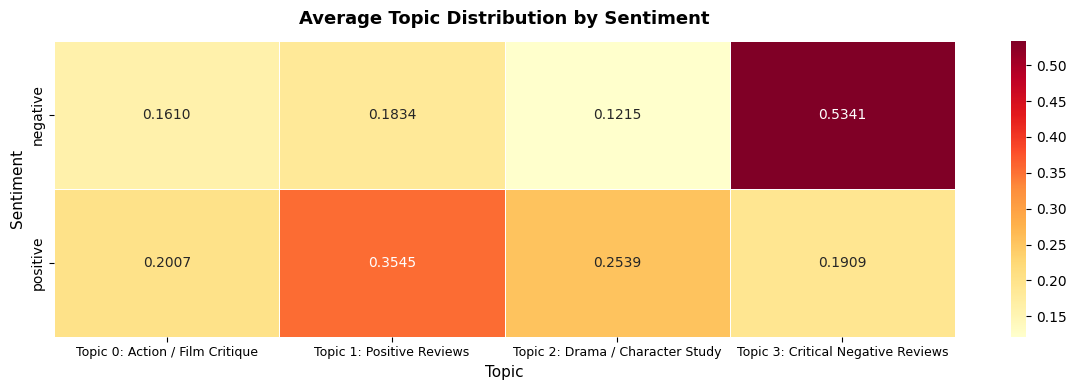

In [16]:
# ── Average topic distribution per sentiment group ────────────────────────────

topic_cols = [f"Topic {i}" for i in range(4)]
heatmap_data = topic_df.groupby("sentiment")[topic_cols].mean()

# Rename columns to descriptive labels matching your best LDA run
heatmap_data.columns = [
    "Topic 0: Action / Film Critique",
    "Topic 1: Positive Reviews",
    "Topic 2: Drama / Character Study",
    "Topic 3: Critical Negative Reviews"
]

# ── Plot heatmap ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title("Average Topic Distribution by Sentiment", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Topic", fontsize=11)
ax.set_ylabel("Sentiment", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

**Question:** Does any topic clearly dominate one sentiment?

* Based on the heatmap, it is clear that Topic 3 (Critical Negative Reviews) dominated the negative sentiment with a value of `0.5341`.

## **Print 3 sample reviews**

In [17]:
# ── Print 3 sample reviews per topic with dominant probability > 0.6 ──────────

topic_labels = {
    0: "Action / Film Critique",
    1: "Positive Reviews",
    2: "Drama / Character Study",
    3: "Critical Negative Reviews"
}

for topic_id in range(4):
    col = f"Topic {topic_id}"

    # Filter reviews where this topic dominates > 0.6
    dominant_mask = topic_df[col] > 0.6
    dominant_indices = topic_df[dominant_mask].index.tolist()

    print(f"\n{'=' * 65}")
    print(f"  Topic {topic_id}: {topic_labels[topic_id]}")
    print(f"  {dominant_mask.sum()} reviews with dominant probability > 0.6")
    print(f"{'=' * 65}")

    if len(dominant_indices) == 0:
        print("  No reviews found with dominance > 0.6 for this topic.")
        continue

    # Sample up to 3
    samples = topic_df[dominant_mask].sample(
        min(3, len(dominant_indices)), random_state=42
    )

    for idx, row in samples.iterrows():
        print(f"\n  Review #{idx}  |  Sentiment: {row['sentiment']}")
        print(f"  Topic prob: {row[col]:.4f}")
        print(f"  Original : {df_sample.loc[idx, 'review'][:200]}...")
        print(f"  Cleaned  : {df_sample.loc[idx, 'cleaned_review'][:200]}...")


  Topic 0: Action / Film Critique
  299 reviews with dominant probability > 0.6

  Review #1898  |  Sentiment: negative
  Topic prob: 0.9960
  Original : I read some gushing reviews here on IMDb and thought I would give this movie a look. Disappointed. On the plus side the male leads are good, and some interesting photography but as a whole this movie ...
  Cleaned  : read gushing review imdb thought disappointed plus side male lead interesting photography whole fails convince seems full self indulgent importance trying something meaningful fall short picture uncon...

  Review #1808  |  Sentiment: negative
  Topic prob: 0.9975
  Original : A montage prologue, quite obviously manufactured by the blessed maniacs who actually chose to distribute this thing, tries to convince us that the comic impact of this staggeringly incompetent bit of ...
  Cleaned  : montage prologue quite obviously manufactured blessed maniac actually chose distribute try convince comic impact staggeringly incompe

**Question:** Do the LDA topics align with the sentiment labels, or do they capture something different (e.g., genre, style)? What does this tell you about what LDA discovers vs. what sentiment analysis predicts?

* We can see 4 topics here with top 12 words, for topic 0, it is the Action / Film Critique side of the reviews with words like: director, actor, plot, acting, action. We can see how they are all correlated in the technical merit of the movie.
* For topic 1, we have the Positive Reviews series side, where the high weight of show, story, love, play, and best show.
* For topic 2, we have the Drama, with story, love, work, life, and people being the ones with high weight. It could also be the Character Study side with the words young, role, woman and performance.
* For topic 3, we have a unique topic, with the only topic to have "worst" as a top word, which leads me to believe that this is the Critical Negative Reviews Study side of the topics with words like people, acting, story, plot, better, worst, and funny, which are all words that you use in a review. This topic has a high likelihood of leading the negative sentiment group.
* Topics 0-2 has all the positive words like great and best which will probably lead the postive sentiments.
* For the common theme, there's always director, acting or plot in the topics which are a common theme.
* LDA discovers the content and context of the reviews while sentiment analysis predicts atittude and emotion.

# **Comparison & Evaluation**

## **Compute**

In [18]:
# ── Encode true sentiment labels to numeric ────────────────────────────────────

true_labels = (df_sample["sentiment"] == "positive").astype(int).values

# K-Means evaluation
ari_km = adjusted_rand_score(true_labels, cluster_labels)
nmi_km = normalized_mutual_info_score(true_labels, cluster_labels)
sil = silhouette_score(X_norm, cluster_labels, sample_size=500, random_state=42)

print("K-Means Clustering Evaluation")
print("=" * 40)
print(f"Silhouette Score:              {sil:.4f}  (higher is better, max=1)")
print(f"Adjusted Rand Index:           {ari_km:.4f}  (1=perfect, 0=random)")
print(f"Normalized Mutual Information: {nmi_km:.4f}  (1=perfect, 0=no info)")

K-Means Clustering Evaluation
Silhouette Score:              0.0032  (higher is better, max=1)
Adjusted Rand Index:           0.1557  (1=perfect, 0=random)
Normalized Mutual Information: 0.1325  (1=perfect, 0=no info)


## **Assign each document its dominant LDA topic**

In [19]:
# ── LDA Dominant Topic Assignment ─────────────────────────────────────────────

topic_cols = [f"Topic {i}" for i in range(4)]
topic_df["dominant_topic"] = topic_df[topic_cols].idxmax(axis=1)
topic_df["dominant_topic"] = topic_df["dominant_topic"].str.extract(r"(\d+)").astype(int)

ari_lda = adjusted_rand_score(true_labels, topic_df["dominant_topic"])
nmi_lda = normalized_mutual_info_score(true_labels, topic_df["dominant_topic"])

# ── Print results ──────────────────────────────────────────────────────────────

print("=" * 50)
print("  Evaluation Metrics: K-Means vs LDA")
print("=" * 50)
print(f"  {'Metric':<22} {'K-Means':>10} {'LDA':>10}")
print(f"  {'-' * 44}")
print(f"  {'Silhouette Score':<22} {sil:>10.4f} {'N/A':>10}")
print(f"  {'ARI':<22} {ari_km:>10.4f} {ari_lda:>10.4f}")
print(f"  {'NMI':<22} {nmi_km:>10.4f} {nmi_lda:>10.4f}")
print("=" * 50)

print("\nDominant topic distribution (LDA):")
print(topic_df["dominant_topic"].value_counts().sort_index())

  Evaluation Metrics: K-Means vs LDA
  Metric                    K-Means        LDA
  --------------------------------------------
  Silhouette Score           0.0032        N/A
  ARI                        0.1557     0.0959
  NMI                        0.1325     0.0769

Dominant topic distribution (LDA):
dominant_topic
0    362
1    545
2    352
3    741
Name: count, dtype: int64


## **Summarize**

| **Method** | **Silhouette** | **ARI** | **NMI** | **Coherence** |
|---|---|---|---|---:|
| K-Means | 0.0032 | 0.1557 | 0.1325 | N/A |
| LDA | N/A | 0.0959 | 0.0769 | 0.2856 |

**Question:** Based on your results, which method better recovers the sentiment structure of the reviews? Explain why you think clustering or topic modeling is more appropriate for this specific dataset and task.

* In my opinion, K-Means is the better method to use for sentiment recovery because sentiment recovery is often driven by a distinct subset of emotional vocabulary.
* In contrast, LDA is designed to discover topics which is not as useful for sentiment recovery but is still useable for grouping the words into specific topics to make the code more interpretable.
* Overall, K-Means is an opinion-driven model which is better at finding the sentiment and LDA is subject-driven model that is best at finding the categories which means K-Means is the better option as the purpose is to recover the sentiments.

# **References:**

Anthropic. (2025). Claude. Claude.ai. https://claude.ai/new <br>